# SmartPremium: Predicting Insurance Costs with Machine Learning

**Goal:** predict the insurance *Premium Amount* from customer characteristics and policy details.

**Contents**
1. Understanding the data (structure, EDA)
2. Data preprocessing & feature engineering
3. Model development: Linear Regression, Decision Tree, Random Forest, XGBoost (+ hyperparameter tuning)
4. ML pipeline & MLflow experiment tracking
5. Evaluation of the selected model
6. Deployment (Streamlit)
7. Conclusions

The reusable code lives in `src/` (data loading, feature engineering, models, training with MLflow) and
`app/app.py` (Streamlit). This notebook explains each step and shows the results.
Models are trained with `python -m src.train`; the notebook reads the results it produced.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
BLUE, ORANGE = "#2a78d6", "#eb6834"

DATA_PATH = ROOT / "data" / "insurance_premium_dataset.csv"
TARGET = "Premium Amount"
df = pd.read_csv(DATA_PATH)

## 1. Understanding the data
### 1.1 Structure

In [2]:
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
df.head()

Rows: 278,860   Columns: 20


,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type
0,56.0,Male,99990.0,Married,1.0,Master's,NaN,31.074627,Urban,Comprehensive,NaN,13,320.0,5,308.0,2022-12-10 15:21:39.078837,Poor,Yes,Daily,Condo
1,46.0,Male,2867.0,Single,1.0,Bachelor's,NaN,50.271335,Urban,Comprehensive,NaN,3,694.0,4,517.0,2023-01-31 15:21:39.078837,Good,Yes,Monthly,House
2,32.0,Female,30154.0,Divorced,3.0,Bachelor's,NaN,14.714909,Suburban,Comprehensive,2.0,16,652.0,8,849.0,2023-11-26 15:21:39.078837,Poor,No,Monthly,House
3,60.0,Female,48371.0,Divorced,0.0,PhD,Self-Employed,25.346926,Rural,Comprehensive,1.0,11,330.0,7,927.0,2023-02-27 15:21:39.078837,Poor,No,Rarely,Condo
4,25.0,Female,54174.0,Divorced,0.0,High School,Self-Employed,6.659499,Urban,Comprehensive,NaN,9,NaN,8,303.0,2020-11-25 15:21:39.078837,Poor,No,Rarely,Condo


In [3]:
pd.DataFrame({"dtype": df.dtypes.astype(str), "non-null": df.notna().sum(),
              "unique": df.nunique(), "example": df.iloc[0]})

,dtype,non-null,unique,example
Age,float64,274175,47,56.0
Gender,object,278860,2,Male
Annual Income,float64,264905,101693,99990.0
Marital Status,object,273841,3,Married
Number of Dependents,float64,250974,5,1.0
Education Level,object,278860,4,Master's
Occupation,object,197572,3,NaN
Health Score,float64,268263,268263,31.074627
Location,object,278860,3,Urban
Policy Type,object,278860,3,Comprehensive


Observations:
- 278,860 rows and 20 columns (19 features + the target), matching the project brief.
- **Incorrect data types:** `Policy Start Date` is text (with a time component) and must be parsed;
  whole-number fields such as `Age`, `Number of Dependents` and `Previous Claims` are stored as floats because they contain missing values.
- `Customer Feedback` is short text with three values (Poor / Average / Good), so it can be treated as an ordinal feature.

### 1.2 Missing values

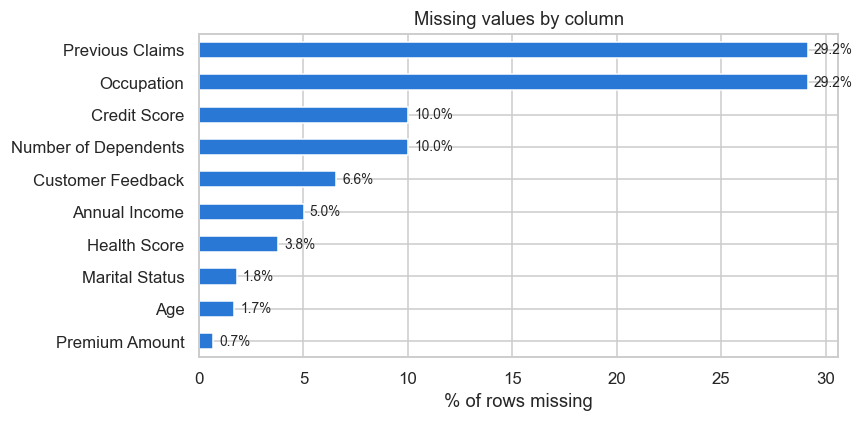

,% missing
Previous Claims,29.15
Occupation,29.15
Credit Score,10.00
Number of Dependents,10.00
Customer Feedback,6.58
Annual Income,5.00
Health Score,3.80
Marital Status,1.80
Age,1.68
Premium Amount,0.66


In [4]:
missing = df.isna().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0]
ax = missing.plot.barh(figsize=(8, 4), color=BLUE)
ax.invert_yaxis()
ax.set(title="Missing values by column", xlabel="% of rows missing")
for i, v in enumerate(missing):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout(); plt.show()
missing.round(2).to_frame("% missing")

`Occupation` and `Previous Claims` are missing for about 29% of rows; several other columns for 2–10%.
The target is missing for 1,841 rows (0.7%); those rows cannot be used for training and are dropped.
Numeric gaps are filled with the **median** and categorical gaps with the **mode**, as specified in the brief.

### 1.3 Distributions of numeric features and the target

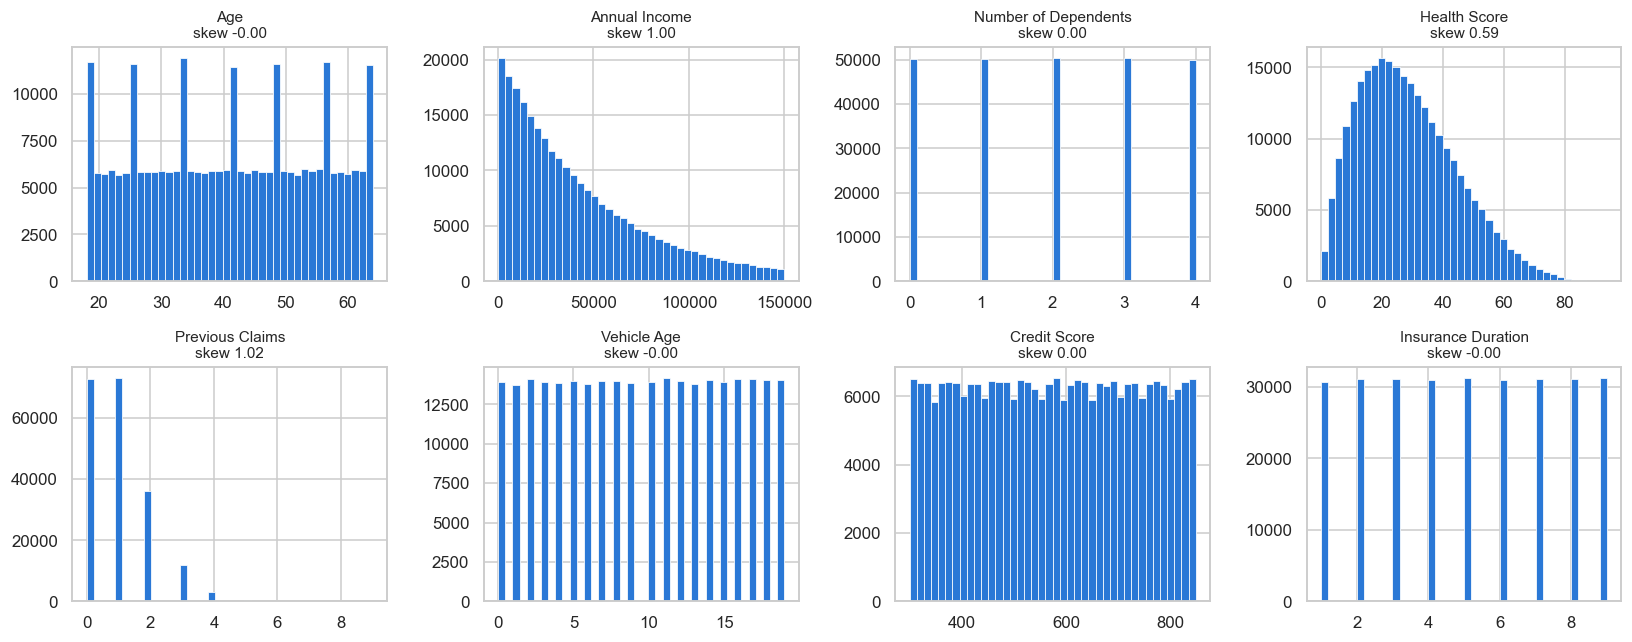

In [5]:
num_cols = df.select_dtypes("number").columns.drop(TARGET)
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col in zip(axes.ravel(), num_cols):
    ax.hist(df[col].dropna(), bins=40, color=BLUE, edgecolor="white", linewidth=0.5)
    ax.set_title(f"{col}\nskew {df[col].skew():.2f}", fontsize=10)
plt.tight_layout(); plt.show()

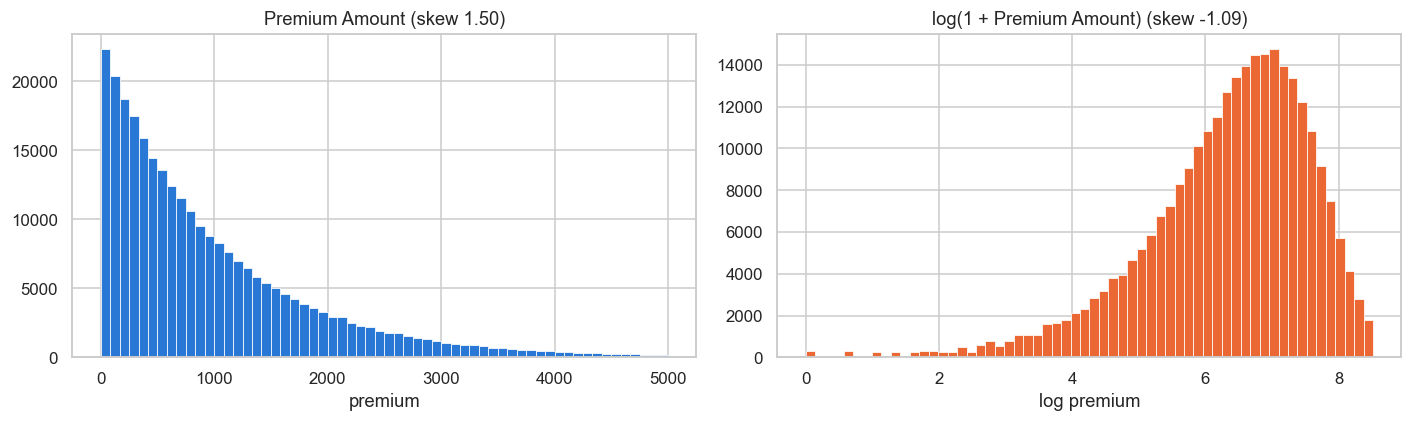

,count,mean,std,min,25%,50%,75%,max
Premium Amount,277019.0,966.1,909.4,0.0,286.0,688.0,1367.0,4999.0


In [6]:
y = df[TARGET].dropna()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.hist(y, bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
a1.set(title=f"Premium Amount (skew {y.skew():.2f})", xlabel="premium")
a2.hist(np.log1p(y), bins=60, color=ORANGE, edgecolor="white", linewidth=0.5)
a2.set(title=f"log(1 + Premium Amount) (skew {np.log1p(y).skew():.2f})", xlabel="log premium")
plt.tight_layout(); plt.show()
y.describe().round(1).to_frame().T

- `Annual Income`, `Health Score` and the target are right-skewed. The premium ranges from 0 to 4,999 with a median of 688.
- After a log transform the target is left-skewed instead; there is a cluster of very small premiums.
  Because the main evaluation metric is **RMSLE**, the models are trained on `log(1 + premium)`, which optimises RMSLE directly.
- `Previous Claims` has a long tail (up to 9 claims), so it is capped at 5 during feature engineering.

### 1.4 Categorical features

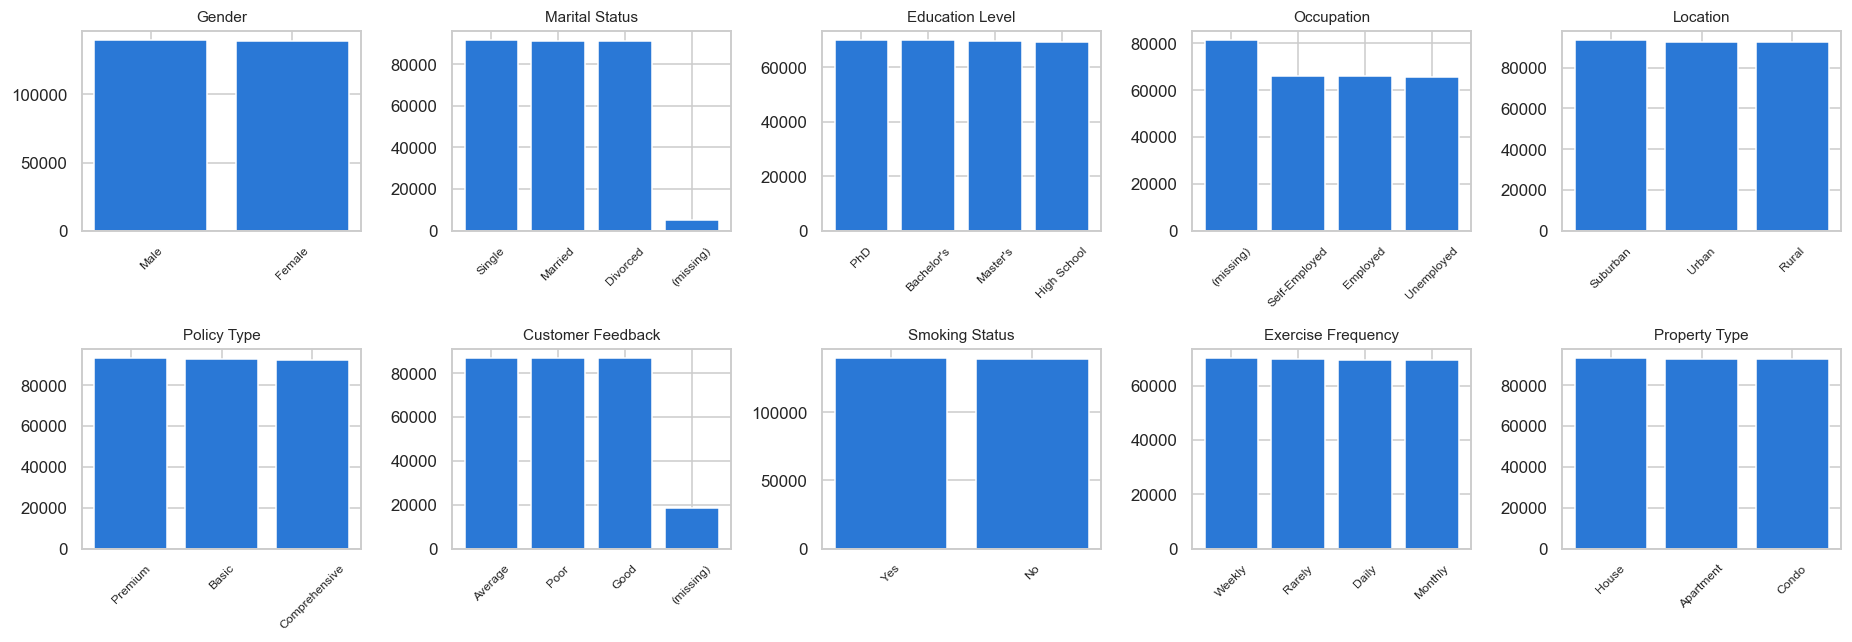

In [7]:
cat_cols = [c for c in df.select_dtypes("object").columns if c != "Policy Start Date"]
fig, axes = plt.subplots(2, 5, figsize=(17, 6))
for ax, col in zip(axes.ravel(), cat_cols):
    counts = df[col].fillna("(missing)").value_counts()
    ax.bar(counts.index, counts.values, color=BLUE)
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout(); plt.show()

All categorical features are almost perfectly balanced across their levels, typical of a synthetic dataset.

### 1.5 Relationships between features and the premium

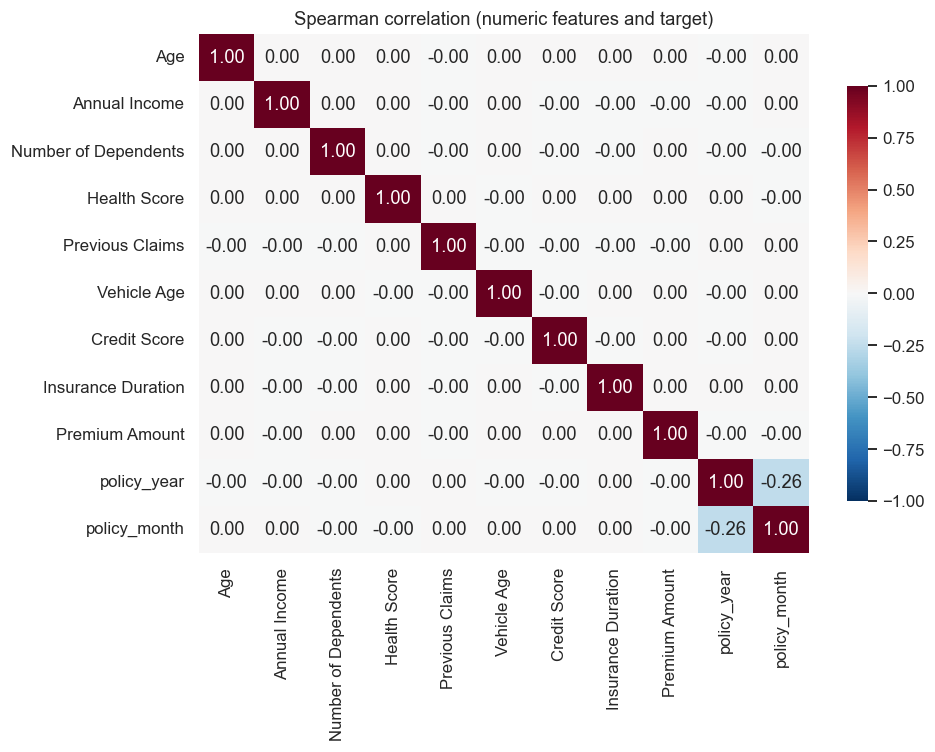

,|corr| with premium
Credit Score,0.0035
Age,0.0030
Health Score,0.0023
Insurance Duration,0.0023
policy_year,0.0013
Number of Dependents,0.0012
Previous Claims,0.0011
Annual Income,0.0008
policy_month,0.0006
Vehicle Age,0.0002


In [8]:
dates = pd.to_datetime(df["Policy Start Date"], errors="coerce")
num = df.select_dtypes("number").assign(policy_year=dates.dt.year, policy_month=dates.dt.month)
corr = num.corr(method="spearman")
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, cbar_kws={"shrink": .8})
plt.title("Spearman correlation (numeric features and target)"); plt.tight_layout(); plt.show()
corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).round(4).to_frame("|corr| with premium")

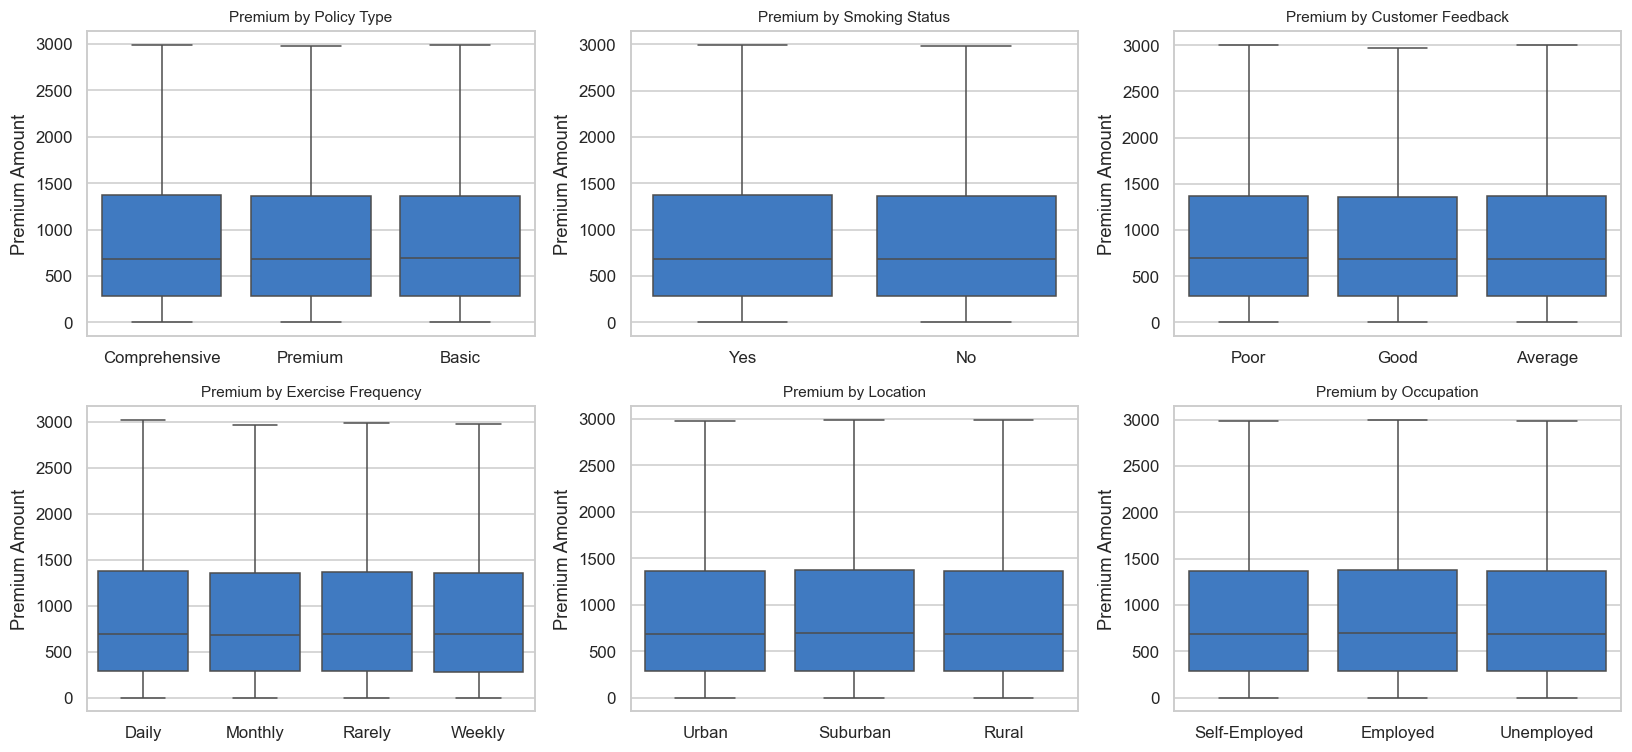

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), ["Policy Type", "Smoking Status", "Customer Feedback",
                                  "Exercise Frequency", "Location", "Occupation"]):
    sns.boxplot(data=df, x=col, y=TARGET, ax=ax, color=BLUE, showfliers=False)
    ax.set_title(f"Premium by {col}", fontsize=10); ax.set_xlabel("")
plt.tight_layout(); plt.show()

In [10]:
from sklearn.feature_selection import mutual_info_regression

sample = df.dropna(subset=[TARGET]).sample(50_000, random_state=0)
X_mi = sample.drop(columns=[TARGET, "Policy Start Date"])
for c in X_mi.select_dtypes("object"):
    X_mi[c] = X_mi[c].astype("category").cat.codes
X_mi = X_mi.fillna(X_mi.median())
mi = pd.Series(mutual_info_regression(X_mi, np.log1p(sample[TARGET]), random_state=0), index=X_mi.columns)
mi.sort_values(ascending=False).round(4).to_frame("mutual information with log premium")

,mutual information with log premium
Previous Claims,0.0045
Gender,0.0042
Credit Score,0.0033
Number of Dependents,0.0030
Policy Type,0.0029
Exercise Frequency,0.0027
Annual Income,0.0022
Insurance Duration,0.0012
Vehicle Age,0.0011
Age,0.0006


**Key EDA finding.** The premium shows essentially **no relationship with any feature**:
- every Spearman correlation with the target is below 0.01 in absolute value;
- the premium distribution is the same for every policy type, smoking status, feedback level, location, etc.;
- mutual information (which also captures non-linear relationships) is close to zero for every feature.

This strongly suggests the target in this synthetic dataset was generated largely independently of the features.
We still follow the full modelling workflow, but we include a **baseline** that always predicts the same typical premium,
so that every model can be judged against "no information".

## 2. Data preprocessing & feature engineering

All steps are implemented as scikit-learn transformers (`src/preprocessing.py`) so the identical logic runs during
training, evaluation and in the Streamlit app.

| Step | Implementation |
|---|---|
| Fix data types | parse `Policy Start Date` → `policy_year`, `policy_month`, `policy_dayofweek`, `policy_age_days`; map `Customer Feedback` → ordinal `feedback_score` (Poor 0, Average 1, Good 2) |
| Skew & outliers | `log_annual_income`; `Previous Claims` capped at 5 |
| New features | `income_per_dependent`, `n_missing` (number of missing fields per row) |
| Missing values | numeric → median, categorical → most frequent (mode) |
| Encoding | one-hot encoding for categorical features |
| Scaling | `StandardScaler` for numeric features |
| Target | trained on `log1p(premium)`, predictions converted back with `expm1` |
| Split | 80% training / 20% evaluation (`random_state=42`) |

In [11]:
from src.data import load_data
from src.preprocessing import FeatureEngineer, build_preprocessor

X, y = load_data(str(DATA_PATH))
print(f"After dropping rows without a target: {len(X):,} rows")

fe = FeatureEngineer().fit(X)
X_fe = fe.transform(X)
X_fe.head(3).T

After dropping rows without a target: 277,019 rows


,0,1,2
Age,56.0,46.0,32.0
Gender,Male,Male,Female
Annual Income,99990.0,2867.0,30154.0
Marital Status,Married,Single,Divorced
Number of Dependents,1.0,1.0,3.0
Education Level,Master's,Bachelor's,Bachelor's
Occupation,NaN,NaN,NaN
Health Score,31.074627,50.271335,14.714909
Location,Urban,Urban,Suburban
Policy Type,Comprehensive,Comprehensive,Comprehensive


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preprocessor, num_feats, cat_feats = build_preprocessor(X_fe)
Xt = preprocessor.fit_transform(fe.transform(X_train))
print(f"Train: {len(X_train):,} rows   Test: {len(X_test):,} rows")
print(f"{len(num_feats)} numeric + {len(cat_feats)} categorical columns -> {Xt.shape[1]} model features after one-hot encoding")
print("Missing values after preprocessing:", int(np.isnan(Xt).sum()))

Train: 221,615 rows   Test: 55,404 rows
16 numeric + 9 categorical columns -> 43 model features after one-hot encoding
Missing values after preprocessing: 0


## 3. Model development

`src/models.py` defines the candidates and `src/train.py` trains them:

- **Baseline** – ignores all features and always predicts the mean of log(1 + premium), the best constant prediction for RMSLE
- **Linear Regression**
- **Decision Tree** – tuned: `max_depth`, `min_samples_leaf`
- **Random Forest** – tuned: `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features`
- **XGBoost** – tuned: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`, `reg_lambda`

**Hyperparameter tuning:** `RandomizedSearchCV` (12 candidates × 3-fold CV, scored by RMSLE) on a 40,000-row
sample of the training set; the best configuration is then refitted on the full 221,615-row training set and
evaluated once on the 55,404-row test set with **RMSLE, RMSE, MAE and R²**.

Run with: `python -m src.train`

In [13]:
info = json.loads((ROOT / "models" / "model_info.json").read_text())
comparison = pd.read_csv(ROOT / "reports" / "model_comparison.csv")
comparison.drop(columns=["best_params"]).style.format(precision=4).hide(axis="index")

model,rmsle,rmse,mae,r2,cv_rmsle,train_seconds
xgboost,1.2559,1002.4479,674.0033,-0.2065,1.2668,49.7000
random_forest,1.2559,1002.4387,674.0174,-0.2064,1.2667,49.0000
baseline_mean,1.2560,1002.4479,674.0396,-0.2065,nan,1.1000
linear_regression,1.2561,1002.4906,674.0831,-0.2066,nan,1.3000
decision_tree,1.2566,1002.5745,674.2898,-0.2068,1.2687,12.8000


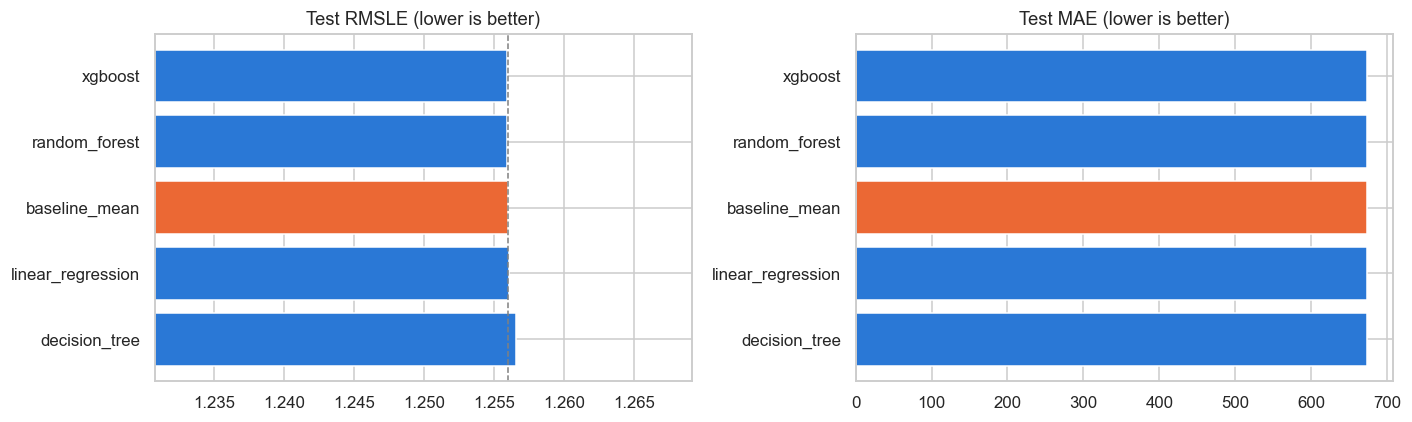

Best model: xgboost  |  RMSLE 1.2559 vs baseline 1.2560 (0.005% better)
Best hyperparameters: {'colsample_bytree': 0.7962072844310213, 'learning_rate': 0.01696756190799966, 'max_depth': 4, 'min_child_weight': 7, 'n_estimators': 120, 'reg_lambda': 5.0049925196954295, 'subsample': 0.6053059844639466}


In [14]:
comp = comparison.set_index("model")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
order = comp["rmsle"].sort_values().index
axes[0].barh(order, comp.loc[order, "rmsle"], color=[ORANGE if m == "baseline_mean" else BLUE for m in order])
axes[0].axvline(comp.loc["baseline_mean", "rmsle"], color="gray", ls="--", lw=1)
axes[0].set(title="Test RMSLE (lower is better)", xlim=(comp["rmsle"].min() * 0.98, comp["rmsle"].max() * 1.01))
axes[0].invert_yaxis()
axes[1].barh(order, comp.loc[order, "mae"], color=[ORANGE if m == "baseline_mean" else BLUE for m in order])
axes[1].set(title="Test MAE (lower is better)")
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

best, base = info["best_model"], comp.loc["baseline_mean"]
gain = 100 * (base["rmsle"] - comp.loc[best, "rmsle"]) / base["rmsle"]
print(f"Best model: {best}  |  RMSLE {comp.loc[best, 'rmsle']:.4f} vs baseline {base['rmsle']:.4f} ({gain:.3f}% better)")
print("Best hyperparameters:", info["best_params"])

**Reading the results**
- The models are ranked by **RMSLE**, the project's primary metric, and the model with the lowest test RMSLE is deployed.
- All models land close to the baseline. This is consistent with the EDA: there is very little signal to learn.
- R² on the raw premium scale is negative for the log-trained models. Minimising squared *log* error makes a model
  predict near the *geometric* mean of the premium (a few hundred), which sits below the arithmetic mean (≈ 966).
  That is the right choice for RMSLE but is penalised by RMSE/R², which use the raw scale. A model trained directly
  on the raw premium reaches R² ≈ 0 at best; see the check below.

### 3.1 Is there any signal at all? A shuffled-target check

In [15]:
from sklearn.model_selection import cross_val_score, KFold
from src.models import build_pipeline
from xgboost import XGBRegressor

sub_X, sub_y = X_train.sample(40_000, random_state=1), None
sub_y = y_train.loc[sub_X.index]
model = build_pipeline(XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, tree_method="hist", n_jobs=-1))
cv = KFold(3, shuffle=True, random_state=0)
rmsle_scorer = lambda est, X_, y_: -np.sqrt(np.mean((np.log1p(np.maximum(est.predict(X_), 0)) - np.log1p(y_)) ** 2))

real = -cross_val_score(model, sub_X, sub_y, cv=cv, scoring=rmsle_scorer)
shuffled = -cross_val_score(model, sub_X, sub_y.sample(frac=1, random_state=2).values, cv=cv, scoring=rmsle_scorer)
raw_r2 = cross_val_score(build_pipeline(XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                                                       tree_method="hist", n_jobs=-1)).regressor,
                         sub_X, sub_y, cv=cv, scoring="r2")
print(f"XGBoost CV RMSLE with the real target:     {real.mean():.4f}")
print(f"XGBoost CV RMSLE with a shuffled target:   {shuffled.mean():.4f}")
print(f"XGBoost CV R² trained on the raw premium:  {raw_r2.mean():.4f}")

XGBoost CV RMSLE with the real target:     1.2567
XGBoost CV RMSLE with a shuffled target:   1.2556
XGBoost CV R² trained on the raw premium:  -0.0108


If the features carried information about the premium, the model would score clearly better on the real target
than on a randomly shuffled one. The two scores are essentially the same, and an XGBoost model trained directly on the
raw premium explains roughly none of its variance (R² ≈ 0). The dataset's premium is therefore not predictable from
these features; the honest best-possible model performs at about the level of the baseline.

## 4. ML pipeline & MLflow

The whole workflow is one scikit-learn object, so it can be trained, logged, saved and served as a unit:

```
TransformedTargetRegressor(log1p / expm1)
└── Pipeline
    ├── features      FeatureEngineer      (dates, feedback, log income, caps, missing count)
    ├── preprocessor  ColumnTransformer    (median/mode imputation, scaling, one-hot)
    └── model         LinearRegression | DecisionTree | RandomForest | XGBoost
```

`src/train.py` logs **one MLflow run per model** to the `SmartPremium` experiment (`sqlite:///mlflow.db`) with:
- parameters: model name, best hyperparameters, training size
- metrics: `test_rmsle`, `test_rmse`, `test_mae`, `test_r2`, `cv_rmsle`
- the fitted pipeline as an MLflow model (with an input example and signature)

Browse the runs with `mlflow ui --backend-store-uri sqlite:///mlflow.db` → http://127.0.0.1:5000

In [16]:
import mlflow

mlflow.set_tracking_uri(f"sqlite:///{ROOT / 'mlflow.db'}")
runs = mlflow.search_runs(experiment_names=["SmartPremium"], order_by=["metrics.test_rmsle ASC"])
cols = ["tags.mlflow.runName", "metrics.test_rmsle", "metrics.test_rmse", "metrics.test_mae",
        "metrics.test_r2", "metrics.cv_rmsle", "start_time"]
runs[cols].rename(columns=lambda c: c.split(".")[-1]).head(10)

2026/10/04 08:26:29 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/10/04 08:26:29 INFO mlflow.store.db.utils: Updating database tables


INFO  [alembic.runtime.migration] Context impl SQLiteImpl.


INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


INFO  [alembic.runtime.migration] Context impl SQLiteImpl.


INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


,runName,test_rmsle,test_rmse,test_mae,test_r2,cv_rmsle,start_time
0,xgboost,1.255886,1002.447863,674.003343,-0.206466,1.266849,2026-10-04 02:56:05.721000+00:00
1,random_forest,1.255914,1002.438693,674.017419,-0.206444,1.266670,2026-10-04 02:55:13.876000+00:00
2,baseline_mean,1.255954,1002.447855,674.039586,-0.206466,NaN,2026-10-04 02:54:04.838000+00:00
3,linear_regression,1.256064,1002.490559,674.083096,-0.206569,NaN,2026-10-04 02:54:08.373000+00:00
4,decision_tree,1.256564,1002.574538,674.289808,-0.206771,1.268744,2026-10-04 02:54:22.856000+00:00


## 5. Evaluation of the deployed model

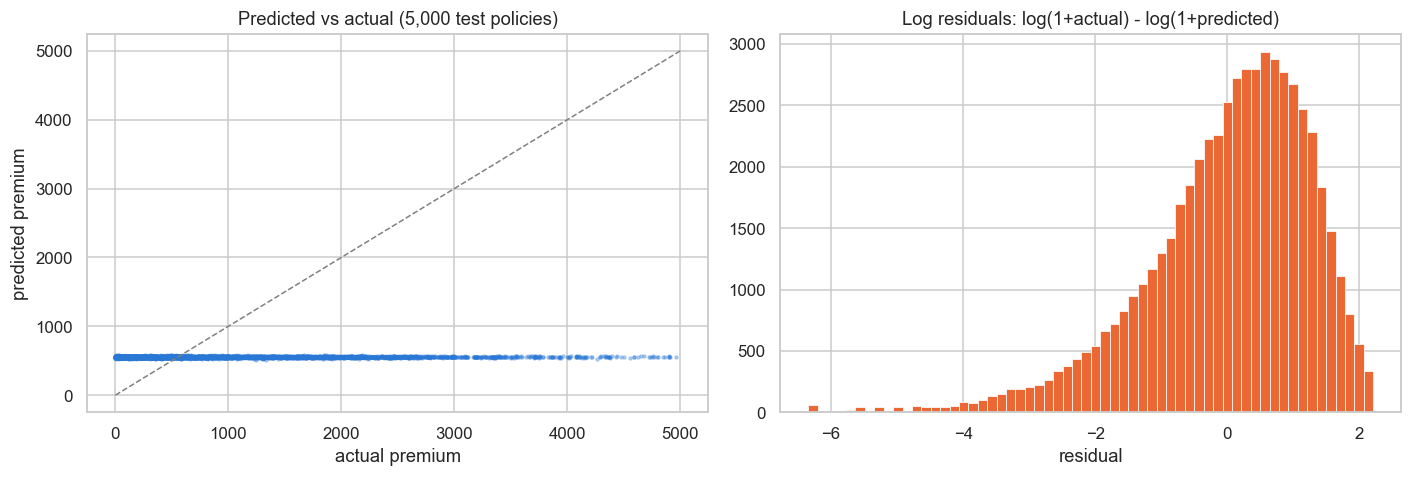

Prediction range: 504 - 616  (actual: 0 - 4998)


In [17]:
import joblib

pipeline = joblib.load(ROOT / "models" / "pipeline.pkl")
pred = np.maximum(pipeline.predict(X_test), 0)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
idx = np.random.default_rng(0).choice(len(y_test), 5000, replace=False)
axes[0].scatter(y_test.values[idx], pred[idx], s=4, alpha=0.3, color=BLUE)
axes[0].plot([0, 5000], [0, 5000], color="gray", ls="--", lw=1)
axes[0].set(title="Predicted vs actual (5,000 test policies)", xlabel="actual premium", ylabel="predicted premium")
axes[1].hist(np.log1p(y_test) - np.log1p(pred), bins=60, color=ORANGE, edgecolor="white", linewidth=0.5)
axes[1].set(title="Log residuals: log(1+actual) - log(1+predicted)", xlabel="residual")
plt.tight_layout(); plt.show()
print(f"Prediction range: {pred.min():.0f} - {pred.max():.0f}  (actual: {y_test.min():.0f} - {y_test.max():.0f})")

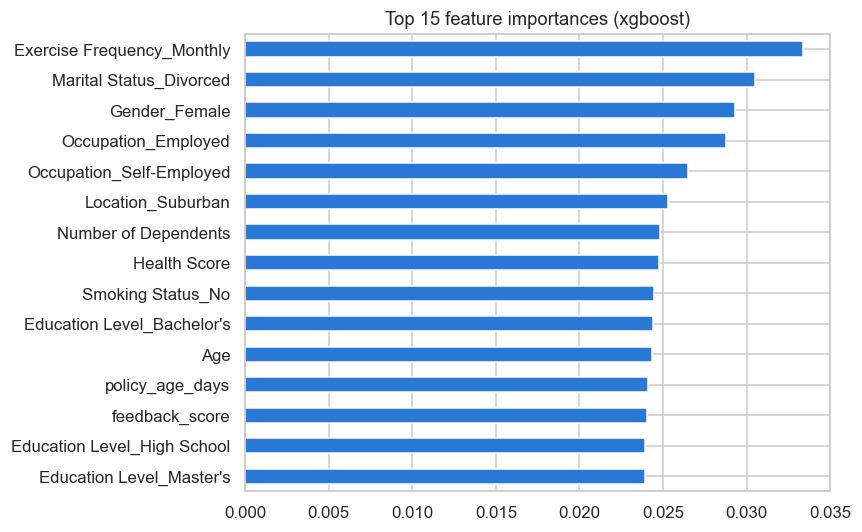

In [18]:
model = pipeline.regressor_.named_steps["model"]
if hasattr(model, "feature_importances_"):
    names = pipeline.regressor_.named_steps["preprocessor"].get_feature_names_out()
    imp = pd.Series(model.feature_importances_, index=names).sort_values(ascending=False).head(15)
    ax = imp[::-1].plot.barh(figsize=(8, 5), color=BLUE)
    ax.set(title=f"Top 15 feature importances ({info['best_model']})")
    plt.tight_layout(); plt.show()
else:
    print(f"{info['best_model']} has no feature importances.")

The predictions are concentrated in a narrow band around the typical premium, as expected when the features
carry little information. Feature importances show which inputs the model leans on most, but given the near-zero
correlations above they should not be interpreted as real pricing drivers.

## 6. Deployment – Streamlit app

`app/app.py` serves the saved pipeline:
- **Get a quote:** input form for all customer and policy details (optional fields may be left as *Unknown* and are imputed),
  returning a real-time premium estimate together with the typical premium range;
- **Batch predictions:** upload a CSV and download predictions for every row;
- **Model performance:** the model-comparison table and an explanation of the results.

Run locally with `streamlit run app/app.py`. To deploy on **Streamlit Community Cloud**: push the repository to GitHub,
sign in at share.streamlit.io, choose the repo and set the main file to `app/app.py`.

## 7. Conclusions

1. **Data quality work was required** – text dates, ordinal text feedback, ~29% missing occupation/claims data,
   skewed income and target, and claim outliers were all handled in a reusable pipeline.
2. **Four required model families were trained and tuned**, tracked in MLflow and compared against a baseline.
   The best model by RMSLE is deployed in the Streamlit app.
3. **The premium in this dataset is essentially unpredictable from the given features.** Correlation, mutual information,
   group comparisons and a shuffled-target test all agree. The best achievable RMSLE is therefore no better than predicting
   the same value for every customer. On real insurance data, the same pipeline would capture genuine risk factors
   (age, health, smoking, claims history).
4. **Recommendations:** collect features that actually drive pricing (e.g. coverage amount, claim costs, vehicle value,
   medical history), check how the target was generated, and keep the baseline in every comparison so that model gains
   are measured honestly.